# THỰC NGHIỆM MÁY HỌC — CODE VÀ KẾT QUẢ DO GIÁO VIÊN CHUẨN BỊ
Giáo viên chạy toàn bộ notebook trước buổi thi. Sinh viên đọc code và output đã lưu; không cần chạy ô nào.
Các mục N0–N7 là địa chỉ tham chiếu trong ngân hàng câu hỏi.
Dữ liệu thật được đóng gói sẵn trong scikit-learn: Diabetes (hồi quy) và Breast Cancer Wisconsin (phân loại).
Không dùng kết quả để suy luận lâm sàng; đây là bài tập đọc hiểu thực nghiệm.
Diabetes thay California Housing trong TH02 để chạy không cần tải dữ liệu. Kỹ năng giữ lại: split, scaling, hồi quy, metric và residual. Phân loại giữ dataset TH03.


## N0 — Môi trường và quy ước


In [1]:
from pathlib import Path
import json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
SEED=42
pd.set_option('display.precision',6)
print({'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__,'seed':SEED})
print('Nhãn phân loại: 0=malignant, 1=benign. Các metric P/R/F1 sau đây lấy positive=1 trừ khi ghi khác.')


{'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'sklearn': '1.8.0', 'seed': 42}
Nhãn phân loại: 0=malignant, 1=benign. Các metric P/R/F1 sau đây lấy positive=1 trừ khi ghi khác.


## N1 — Dữ liệu, EDA và chia tập


,split,samples,features,missing_cells
0,reg_train,353,10,0
1,reg_test,89,10,0
2,clf_train,341,30,0
3,clf_val,114,30,0
4,clf_test,114,30,0


Dataset ban đầu: {'diabetes': (442, 10), 'breast_cancer': (569, 30)}
Tỷ lệ lớp trong train phân loại:


,count
target,
0,127
1,214


,count,mean,std,min,25%,50%,75%,max
mean radius,341.0,14.030343,3.550771,6.98100,11.60000,13.17000,15.4900,28.1100
mean texture,341.0,19.183754,4.528923,9.71000,15.86000,18.75000,21.6800,39.2800
mean area,341.0,646.441935,352.949179,143.50000,412.60000,536.90000,744.9000,2499.0000
mean smoothness,341.0,0.096563,0.013524,0.06251,0.08675,0.09676,0.1054,0.1425


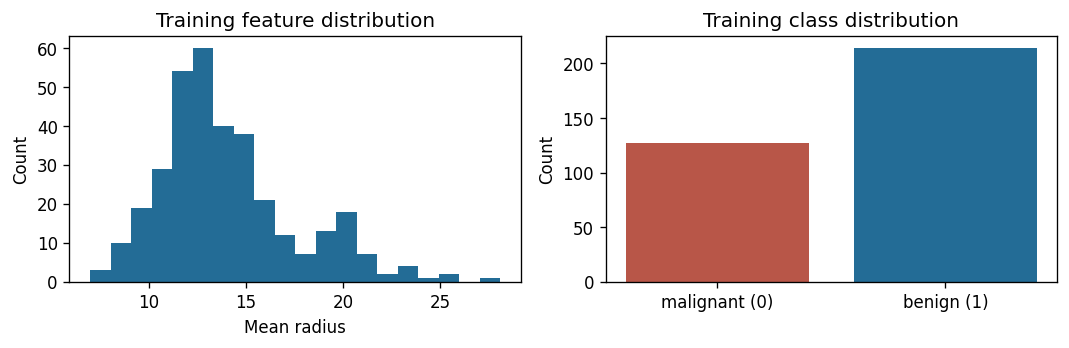

In [2]:
# scaled=False để tránh dùng bản Diabetes đã scale trên toàn dataset.
reg_data=load_diabetes(as_frame=True, scaled=False)
clf_data=load_breast_cancer(as_frame=True)
Xr,yr=reg_data.data,reg_data.target
Xc,yc=clf_data.data,clf_data.target
Xr_train,Xr_test,yr_train,yr_test=train_test_split(Xr,yr,test_size=.2,random_state=SEED)
# Classification: train 60%, validation 20%, test 20% (có làm tròn số mẫu).
Xc_dev,Xc_test,yc_dev,yc_test=train_test_split(Xc,yc,test_size=.2,stratify=yc,random_state=SEED)
Xc_train,Xc_val,yc_train,yc_val=train_test_split(Xc_dev,yc_dev,test_size=.25,stratify=yc_dev,random_state=SEED)
data_rows=[]
for name,X,y in [('reg_train',Xr_train,yr_train),('reg_test',Xr_test,yr_test),('clf_train',Xc_train,yc_train),('clf_val',Xc_val,yc_val),('clf_test',Xc_test,yc_test)]:
    data_rows.append({'split':name,'samples':len(X),'features':X.shape[1],'missing_cells':int(X.isna().sum().sum())})
data_table=pd.DataFrame(data_rows); display(data_table)
print('Dataset ban đầu:',{'diabetes':Xr.shape,'breast_cancer':Xc.shape})
print('Tỷ lệ lớp trong train phân loại:'); display(yc_train.value_counts().sort_index().rename('count').to_frame())
display(Xc_train[['mean radius','mean texture','mean area','mean smoothness']].describe().T)
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].hist(Xc_train['mean radius'],bins=20,color='#236c96'); axes[0].set(xlabel='Mean radius',ylabel='Count',title='Training feature distribution')
axes[1].bar(['malignant (0)','benign (1)'],[int((yc_train==0).sum()),int((yc_train==1).sum())],color=['#b85648','#236c96']); axes[1].set(ylabel='Count',title='Training class distribution')
plt.tight_layout(); plt.show()


## N2 — Fit scaler trên train, áp dụng cho validation


In [3]:
scaler_demo=StandardScaler().fit(Xc_train)
features_demo=['mean radius','mean texture','mean area','mean smoothness']
scaling_rows=[]
for f in features_demo:
    j=Xc_train.columns.get_loc(f); x=float(Xc_val.iloc[0][f]); mu=float(scaler_demo.mean_[j]); s=float(scaler_demo.scale_[j])
    scaling_rows.append({'feature':f,'validation_value_x':x,'train_mean_mu':mu,'train_scale_s':s,'z':(x-mu)/s})
scaling_table=pd.DataFrame(scaling_rows); display(scaling_table)


,feature,validation_value_x,train_mean_mu,train_scale_s,z
0,mean radius,13.87000,14.030343,3.545561,-0.045224
1,mean texture,20.70000,19.183754,4.522277,0.335284
2,mean area,584.80000,646.441935,352.431278,-0.174905
3,mean smoothness,0.09578,0.096563,0.013504,-0.057955


## N3 — Ridge: huấn luyện, baseline và sai số dự đoán


,model,split,MAE,MSE,RMSE,R2
0,Ridge,train,43.494722,2870.296117,53.575145,0.527632
1,Ridge,test,42.811999,2892.014566,53.777454,0.454147
2,Mean train target,test,64.006461,5361.533457,73.222493,-0.011963


,test_position,original_row,actual,predicted,residual,squared_error
0,61,56,52.0,205.386383,-153.386383,23527.382547
1,46,77,200.0,73.592318,126.407682,15978.902144
2,1,211,70.0,179.958241,-109.958241,12090.814676
3,20,9,310.0,207.270269,102.729731,10553.397637


test_position là vị trí mảng; original_row là index dataset, không phải định danh bệnh nhân.


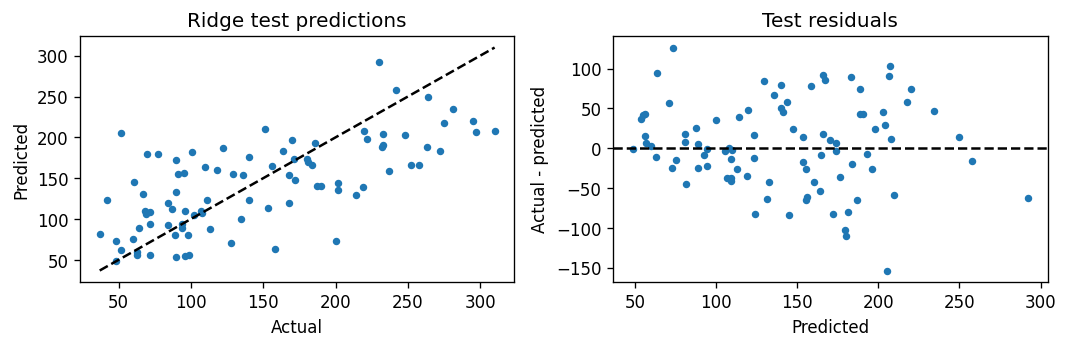

In [4]:
ridge=Pipeline([('scale',StandardScaler()),('reg',Ridge(alpha=1.0))])
ridge.fit(Xr_train,yr_train)
reg_metrics=[]
for split,X,y in [('train',Xr_train,yr_train),('test',Xr_test,yr_test)]:
    p=ridge.predict(X)
    reg_metrics.append({'model':'Ridge','split':split,'MAE':mean_absolute_error(y,p),'MSE':mean_squared_error(y,p),'RMSE':np.sqrt(mean_squared_error(y,p)),'R2':r2_score(y,p)})
baseline=np.full(len(yr_test),yr_train.mean())
reg_metrics.append({'model':'Mean train target','split':'test','MAE':mean_absolute_error(yr_test,baseline),'MSE':mean_squared_error(yr_test,baseline),'RMSE':np.sqrt(mean_squared_error(yr_test,baseline)),'R2':r2_score(yr_test,baseline)})
reg_table=pd.DataFrame(reg_metrics); display(reg_table)
rp=ridge.predict(Xr_test)
errors=pd.DataFrame({'test_position':np.arange(len(yr_test)),'original_row':yr_test.index,'actual':np.asarray(yr_test),'predicted':rp})
errors['residual']=errors.actual-errors.predicted; errors['squared_error']=errors.residual**2
error_cases=errors.nlargest(4,'squared_error').reset_index(drop=True); display(error_cases)
print('test_position là vị trí mảng; original_row là index dataset, không phải định danh bệnh nhân.')
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].scatter(errors.actual,errors.predicted,s=12); lim=[min(errors.actual.min(),errors.predicted.min()),max(errors.actual.max(),errors.predicted.max())]; axes[0].plot(lim,lim,'k--'); axes[0].set(xlabel='Actual',ylabel='Predicted',title='Ridge test predictions')
axes[1].scatter(errors.predicted,errors.residual,s=12); axes[1].axhline(0,color='black',linestyle='--'); axes[1].set(xlabel='Predicted',ylabel='Actual - predicted',title='Test residuals')
plt.tight_layout(); plt.show()


## N4 — Chọn C bằng validation, test chỉ đánh giá sau khi chốt


In [5]:
candidate_models={}; tuning_rows=[]
for C in [.01,.1,1.,10.]:
    model=Pipeline([('scale',StandardScaler()),('clf',LogisticRegression(C=C,max_iter=3000,random_state=SEED))])
    model.fit(Xc_train,yc_train); candidate_models[C]=model
    tuning_rows.append({'C':C,'train_F1':f1_score(yc_train,model.predict(Xc_train)),'validation_F1':f1_score(yc_val,model.predict(Xc_val))})
tuning_table=pd.DataFrame(tuning_rows); display(tuning_table)
# Tie: chọn C nhỏ hơn. Không refit để giữ cùng model cho các bảng sau.
best_C=sorted(tuning_rows,key=lambda r:(-r['validation_F1'],r['C']))[0]['C']
lr=candidate_models[best_C]
tree=DecisionTreeClassifier(max_depth=4,random_state=SEED).fit(Xc_train,yc_train)
print('C được chốt:',best_C,'; Decision Tree max_depth=4, được ấn định trước.')


,C,train_F1,validation_F1
0,0.01,0.963964,0.953020
1,0.10,0.990698,0.979310
2,1.00,0.990698,0.993007
3,10.00,0.990654,0.971831


C được chốt: 1.0 ; Decision Tree max_depth=4, được ấn định trước.


## N5 — Metric và confusion matrix của hai mô hình


In [6]:
class_rows=[]; matrices={}
for name,model in [('Logistic',lr),('Tree',tree)]:
    for split,X,y in [('train',Xc_train,yc_train),('validation',Xc_val,yc_val),('test',Xc_test,yc_test)]:
        p=model.predict(X)
        class_rows.append({'model':name,'split':split,'Accuracy':accuracy_score(y,p),'Precision_1':precision_score(y,p,zero_division=0),'Recall_1':recall_score(y,p,zero_division=0),'F1_1':f1_score(y,p,zero_division=0)})
        if split!='train': matrices[name+'_'+split]=confusion_matrix(y,p,labels=[0,1]).tolist()
class_table=pd.DataFrame(class_rows); display(class_table)
for name,matrix in matrices.items():
    print(name,'— hàng=true, cột=predicted; lớp 0 malignant, lớp 1 benign')
    display(pd.DataFrame(matrix,index=['true 0','true 1'],columns=['pred 0','pred 1']))


,model,split,Accuracy,Precision_1,Recall_1,F1_1
0,Logistic,train,0.988270,0.986111,0.995327,0.990698
1,Logistic,validation,0.991228,0.986111,1.000000,0.993007
2,Logistic,test,0.982456,0.986111,0.986111,0.986111
3,Tree,train,0.985337,0.990610,0.985981,0.988290
4,Tree,validation,0.938596,0.944444,0.957746,0.951049
5,Tree,test,0.912281,0.969697,0.888889,0.927536


Logistic_validation — hàng=true, cột=predicted; lớp 0 malignant, lớp 1 benign


,pred 0,pred 1
true 0,42,1
true 1,0,71


Logistic_test — hàng=true, cột=predicted; lớp 0 malignant, lớp 1 benign


,pred 0,pred 1
true 0,41,1
true 1,1,71


Tree_validation — hàng=true, cột=predicted; lớp 0 malignant, lớp 1 benign


,pred 0,pred 1
true 0,39,4
true 1,3,68


Tree_test — hàng=true, cột=predicted; lớp 0 malignant, lớp 1 benign


,pred 0,pred 1
true 0,40,2
true 1,8,64


## N6 — Thí nghiệm ngưỡng trên validation, không chọn ngưỡng bằng test


In [7]:
prob_val=lr.predict_proba(Xc_val)[:,list(lr.classes_).index(1)]
threshold_rows=[]
for tau in [.3,.4,.5,.6,.7]:
    p=(prob_val>=tau).astype(int); tn,fp,fn,tp=confusion_matrix(yc_val,p,labels=[0,1]).ravel()
    threshold_rows.append({'threshold':tau,'positive_count':int(p.sum()),'TN':int(tn),'FP':int(fp),'FN':int(fn),'TP':int(tp),'Precision_1':precision_score(yc_val,p,zero_division=0),'Recall_1':recall_score(yc_val,p,zero_division=0),'F1_1':f1_score(yc_val,p,zero_division=0)})
threshold_table=pd.DataFrame(threshold_rows); display(threshold_table)
print('Không công bố test metric cho ngưỡng được chọn hậu nghiệm trong bài tập này.')


,threshold,positive_count,TN,FP,FN,TP,Precision_1,Recall_1,F1_1
0,0.3,74,40,3,0,71,0.959459,1.000000,0.979310
1,0.4,73,41,2,0,71,0.972603,1.000000,0.986111
2,0.5,72,42,1,0,71,0.986111,1.000000,0.993007
3,0.6,70,42,1,2,69,0.985714,0.971831,0.978723
4,0.7,70,42,1,2,69,0.985714,0.971831,0.978723


Không công bố test metric cho ngưỡng được chọn hậu nghiệm trong bài tập này.


## N7 — Lưu log từ đúng lần chạy


In [8]:
log_dir=Path('logs'); log_dir.mkdir(exist_ok=True)
results={'seed':SEED,'best_C':best_C,'data':data_rows,'scaling':scaling_rows,'regression':reg_metrics,'error_cases':error_cases.to_dict('records'),'tuning':tuning_rows,'classification':class_rows,'matrices':matrices,'thresholds':threshold_rows,'versions':{'python':platform.python_version(),'sklearn':sklearn.__version__,'pandas':pd.__version__,'numpy':np.__version__}}
(log_dir/'results.json').write_text(json.dumps(results,ensure_ascii=False,indent=2),encoding='utf-8')
with (log_dir/'tables.txt').open('w',encoding='utf-8') as f:
    for name,table in [('N1',data_table),('N2',scaling_table),('N3',reg_table),('N3_cases',error_cases),('N4',tuning_table),('N5',class_table),('N6',threshold_table)]:
        f.write(name+'\n'+table.to_string(index=False)+'\n\n')
print('Đã lưu logs/results.json và logs/tables.txt. Output trực tiếp trong notebook là bản dùng để làm bài.')


Đã lưu logs/results.json và logs/tables.txt. Output trực tiếp trong notebook là bản dùng để làm bài.
